## Five year health trends

Which Mississippi counties improved or worsened on diabetes since 2020. This is the time series part of the project and is useful for showing where the crisis is accelerating versus where it is stable.

### Importing necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv

load_dotenv('../.env')
host = os.getenv('PGHOST', 'localhost')
port = os.getenv('PGPORT', '5432')
db = os.getenv('PGDATABASE', 'ms_health')
user = os.getenv('PGUSER', 'postgres')
pwd = os.getenv('PGPASSWORD', '')
engine = create_engine(f'postgresql+psycopg://{user}:{pwd}@{host}:{port}/{db}')
sns.set(style='whitegrid')

def q(sql):
    return pd.read_sql(text(sql), engine)

### Year over year change and change since baseline in diabetes per county

In [2]:
# Per-county diabetes change since 2020. Three window functions per (county, measure):
#   LAG()         prior-year value
#   FIRST_VALUE() baseline value
#   LAST_VALUE()  most recent value
yoy = q("""
WITH county_yearly AS (
    SELECT g.county_fips, g.county_name, g.region,
        m.measure_id, f.year_sk,
        SUM(f.data_value * f.total_population) / NULLIF(SUM(f.total_population), 0) AS pop_weighted_value
    FROM fact_places f
    JOIN dim_geography g ON g.geo_sk = f.geo_sk
    JOIN dim_measure m ON m.measure_sk = f.measure_sk
    WHERE m.source = 'PLACES'
    AND m.measure_id IN ('DIABETES', 'CSMOKING', 'DEPRESSION', 'OBESITY', 'BPHIGH')
    GROUP BY g.county_fips, g.county_name, g.region, m.measure_id, f.year_sk
),
with_lag AS (
    SELECT *,
        LAG(pop_weighted_value) OVER w AS prior_year_value,
        FIRST_VALUE(pop_weighted_value) OVER w AS baseline_value
    FROM county_yearly
    WINDOW w AS (PARTITION BY county_fips, measure_id ORDER BY year_sk)
)
SELECT county_name, region, measure_id, year_sk,
    ROUND(pop_weighted_value::NUMERIC, 2) AS value,
    ROUND((pop_weighted_value - prior_year_value)::NUMERIC, 2) AS yoy_delta,
    ROUND((pop_weighted_value - baseline_value)::NUMERIC, 2) AS delta_since_baseline,
    CASE WHEN prior_year_value IS NULL THEN 'baseline'
        WHEN pop_weighted_value > prior_year_value THEN 'worsening'
        WHEN pop_weighted_value < prior_year_value THEN 'improving'
        ELSE 'flat' END AS direction
FROM with_lag
WHERE year_sk = (SELECT MAX(year_sk) FROM fact_places)
AND measure_id = 'DIABETES'
ORDER BY delta_since_baseline DESC
LIMIT 20
""")
yoy

,county_name,region,measure_id,year_sk,value,yoy_delta,delta_since_baseline,direction
0,Carroll,Delta,DIABETES,2023,18.69,5.29,5.79,worsening
1,Panola,Delta,DIABETES,2023,18.66,6.76,5.56,worsening
2,Lawrence,Other,DIABETES,2023,18.96,4.89,4.78,worsening
3,Jefferson Davis,Other,DIABETES,2023,21.10,4.54,4.43,worsening
4,Humphreys,Delta,DIABETES,2023,24.76,4.28,4.35,worsening
5,Coahoma,Delta,DIABETES,2023,22.28,3.27,3.83,worsening
6,Montgomery,Other,DIABETES,2023,20.59,4.30,3.79,worsening
7,Benton,Other,DIABETES,2023,17.43,4.03,3.73,worsening
8,Leflore,Delta,DIABETES,2023,21.34,3.05,3.50,worsening
9,Sharkey,Delta,DIABETES,2023,24.45,3.60,3.48,worsening


### Region trends across four chronic disease measures

In [3]:
# Per-region, per-year, per-measure averages for the FacetGrid below.
trends = q("""
SELECT f.year_sk AS year, g.region, m.short_name AS measure,
    AVG(f.data_value) AS value
FROM fact_places f
JOIN dim_geography g ON g.geo_sk = f.geo_sk
JOIN dim_measure m ON m.measure_sk = f.measure_sk
WHERE m.source = 'PLACES'
AND m.measure_id IN ('DIABETES','DEPRESSION','OBESITY','CSMOKING')
GROUP BY f.year_sk, g.region, m.short_name
ORDER BY f.year_sk
""")
trends.head()

,year,region,measure,value
0,2018,Pine Belt,Diabetes,13.585185
1,2018,Other,Current Smoking,24.095855
2,2018,Delta,Diabetes,16.538596
3,2018,Gulf Coast,Obesity,37.922581
4,2018,Other,Obesity,40.753368


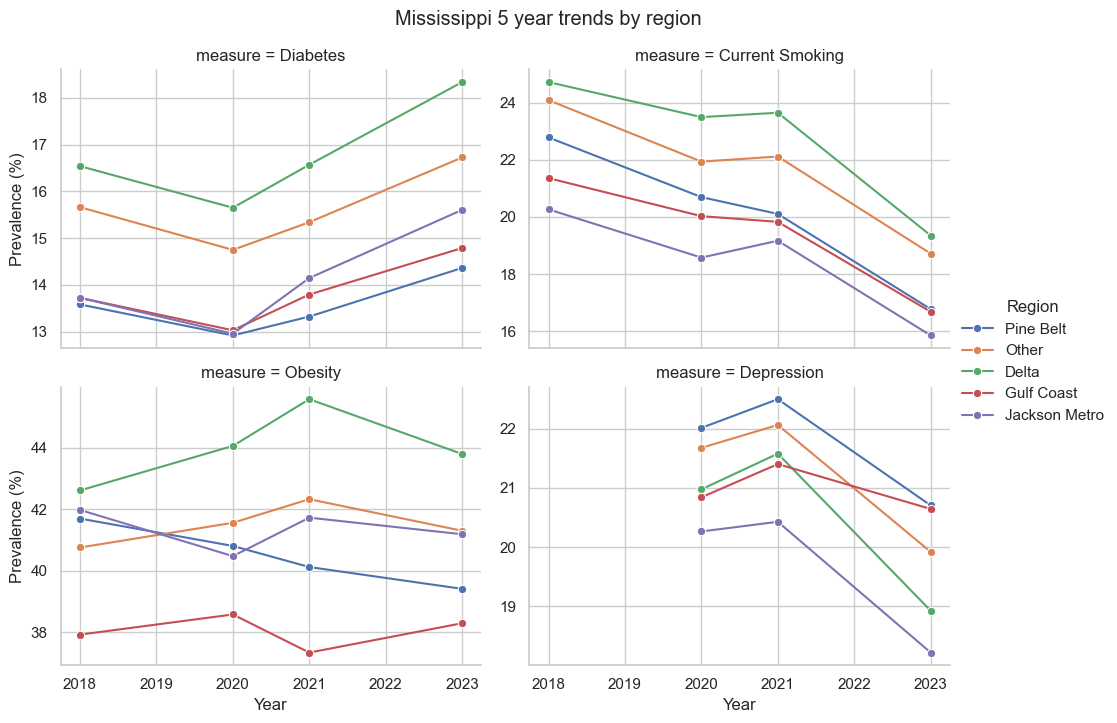

In [4]:
# One panel per measure, one line per region.
g = sns.FacetGrid(trends, col='measure', col_wrap=2,
                  hue='region', height=3.5, aspect=1.4, sharey=False)
g.map(sns.lineplot, 'year', 'value', marker='o')
g.add_legend(title='Region')
g.set_axis_labels('Year', 'Prevalence (%)')
g.fig.suptitle('Mississippi 5 year trends by region', y=1.03)
plt.show()